# 03 — STR Workflow Simulation
## Gaming Compliance & Risk Intelligence Platform

**Phase 6 deliverable.** Turns escalated AML alerts (Phase 5) into investigation
**cases**, simulates the STR case lifecycle, and computes workflow KPIs per
[`documentation/str_workflow.md`](../documentation/str_workflow.md).

> Case-level data (analysts, statuses, dates, closure reasons) is **synthetic** and
> clearly labelled. It integrates with the real (synthetic) alerts from Phase 5.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RNG = np.random.default_rng(7)
AS_OF = pd.Timestamp("2024-07-15")   # reference date for aging open cases

alerts = pd.read_csv("../data_processed/aml_alerts.csv", parse_dates=["Timestamp"])
print(f"Total alerts: {len(alerts):,}")
print(f"Escalated alerts: {int(alerts.Is_Escalated.sum()):,}")


Total alerts: 1,030
Escalated alerts: 398


## 1. Build Case Seed from Escalated Alerts\nOne case per distinct escalated transaction (highest-severity alert).

In [2]:
esc = alerts[alerts.Is_Escalated == 1].copy()
# one case per distinct transaction: keep the highest-scoring alert
esc = esc.sort_values("Risk_Score", ascending=False).drop_duplicates("Transaction_ID")
cases = esc[["Transaction_ID","From_Account","Timestamp","Risk_Score","Severity",
             "Amount_Paid","Is_Laundering"]].reset_index(drop=True)
cases.insert(0, "Case_Key", range(1, len(cases) + 1))
print(f"Cases created: {len(cases):,}")
cases.head()


Cases created: 362


,Case_Key,Transaction_ID,From_Account,Timestamp,Risk_Score,Severity,Amount_Paid,Is_Laundering
0,1,5117,ACC-1091,2024-06-26 00:00:00,95,Critical,5212.44,1
1,2,2555,ACC-1212,2024-05-13 06:19:20,95,Critical,1663.11,1
2,3,4597,ACC-1010,2024-06-16 16:35:33,95,Critical,76.34,1
3,4,5096,ACC-1010,2024-06-25 11:43:47,95,Critical,1535.94,1
4,5,2011,ACC-1141,2024-05-04 03:30:48,95,Critical,239.68,1


## 2. Simulate Case Lifecycle (synthetic)

In [3]:
ANALYSTS = ["AN-001","AN-003","AN-007","AN-011","AN-014","AN-021"]
SLA_BY_PRIORITY = {"Critical": 5, "High": 10, "Medium": 15, "Low": 20}
CLOSED_INV = {"Critical": (1,6), "High": (2,12), "Medium": (4,18), "Low": (6,22)}

# Priority from alert severity
cases["Case_Priority"] = cases["Severity"]
cases["SLA_Days"] = cases["Case_Priority"].map(SLA_BY_PRIORITY)
cases["Analyst_ID"] = RNG.choice(ANALYSTS, size=len(cases))
cases["Open_Date"] = cases["Timestamp"].dt.normalize()

def outcome(is_laundering):
    # outcome path probabilities differ for true laundering vs not
    if is_laundering:
        return RNG.choice(["closed_str","open_str","closed_nostr","open_review"],
                          p=[0.45, 0.20, 0.05, 0.30])
    return RNG.choice(["closed_str","open_str","closed_nostr","open_review"],
                      p=[0.05, 0.05, 0.45, 0.45])

OPEN_REVIEW_STATUSES = ["New","Under Review","Escalated"]
NOSTR_REASONS = ["No suspicious activity confirmed (false positive)",
                 "Insufficient evidence — monitor"]

records = []
for _, r in cases.iterrows():
    path = outcome(r.Is_Laundering)
    pr = r.Case_Priority
    status, str_flag, close_date, closure = None, 0, pd.NaT, None
    if path == "closed_str":
        status, str_flag = "Closed", 1
        inv = int(RNG.integers(*CLOSED_INV[pr]))
        close_date = r.Open_Date + pd.Timedelta(days=inv)
        closure = "STR filed with FINTRAC (synthetic)"
    elif path == "closed_nostr":
        status = "Closed"
        inv = int(RNG.integers(*CLOSED_INV[pr]))
        close_date = r.Open_Date + pd.Timedelta(days=inv)
        closure = RNG.choice(NOSTR_REASONS)
    elif path == "open_str":
        status, str_flag = "STR Submitted", 1
    else:  # open_review
        status = RNG.choice(OPEN_REVIEW_STATUSES)
    records.append((status, str_flag, close_date, closure))

cases[["Status","STR_Submitted_Flag","Close_Date","Closure_Reason"]] = pd.DataFrame(records, index=cases.index)

# Investigation days: closed -> actual; open -> days open as of AS_OF
is_closed = cases["Status"] == "Closed"
cases["Investigation_Days"] = np.where(
    is_closed,
    (cases["Close_Date"] - cases["Open_Date"]).dt.days,
    (AS_OF - cases["Open_Date"]).dt.days)
cases["SLA_Breached"] = (cases["Investigation_Days"] > cases["SLA_Days"]).astype(int)

cases.to_csv("../data_processed/str_cases.csv", index=False)
print(f"Exported {len(cases):,} cases -> ../data_processed/str_cases.csv")
cases[["Case_Key","Analyst_ID","Case_Priority","Status","STR_Submitted_Flag",
       "Investigation_Days","SLA_Days","SLA_Breached","Closure_Reason"]].head()


Exported 362 cases -> ../data_processed/str_cases.csv


,Case_Key,Analyst_ID,Case_Priority,Status,STR_Submitted_Flag,Investigation_Days,SLA_Days,SLA_Breached,Closure_Reason
0,1,AN-021,Critical,Escalated,0,19.0,5,1,None
1,2,AN-011,Critical,STR Submitted,1,63.0,5,1,None
2,3,AN-014,Critical,Escalated,0,29.0,5,1,None
3,4,AN-021,Critical,Closed,1,1.0,5,0,STR filed with FINTRAC (synthetic)
4,5,AN-011,Critical,Closed,1,1.0,5,0,STR filed with FINTRAC (synthetic)


## 3. Workflow KPIs

In [4]:
total_alerts = len(alerts)
escalated = int(alerts.Is_Escalated.sum())
total_cases = len(cases)
backlog = int((cases.Status != "Closed").sum())
strs = int(cases.STR_Submitted_Flag.sum())
closed = cases[cases.Status == "Closed"]
avg_inv = closed.Investigation_Days.mean()
sla_comp = 100 * (closed.SLA_Breached == 0).mean()

kpis = pd.DataFrame({
    "KPI": ["Alert Volume","Escalation Rate","Total Cases","Backlog (open)",
            "STRs Filed","STR Conversion Rate","Avg Investigation Time (closed)",
            "SLA Compliance Rate"],
    "Value": [f"{total_alerts:,}", f"{100*escalated/total_alerts:.1f}%", f"{total_cases:,}",
              f"{backlog:,}", f"{strs:,}", f"{100*strs/total_cases:.1f}%",
              f"{avg_inv:.1f} days", f"{sla_comp:.1f}%"]})
kpis


,KPI,Value
0,Alert Volume,"1,030"
1,Escalation Rate,38.6%
2,Total Cases,362
3,Backlog (open),184
4,STRs Filed,207
5,STR Conversion Rate,57.2%
6,Avg Investigation Time (closed),5.0 days
7,SLA Compliance Rate,93.8%


### Chart: cases by status (pipeline)

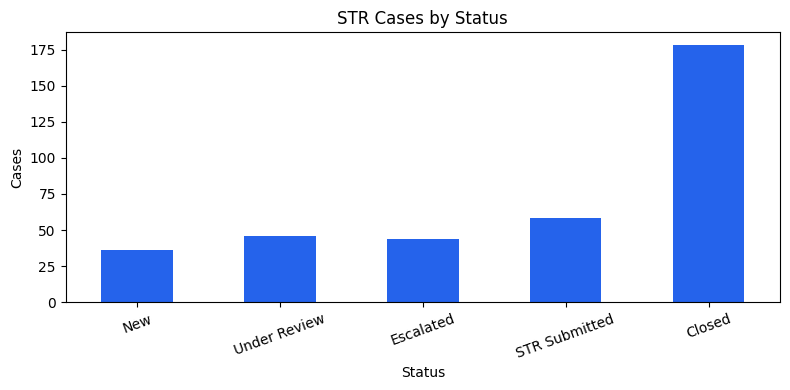

In [5]:
order = ["New","Under Review","Escalated","STR Submitted","Closed"]
by_status = cases.Status.value_counts().reindex(order).fillna(0)
fig, ax = plt.subplots(figsize=(8,4))
by_status.plot(kind="bar", ax=ax, color="#2563eb")
ax.set_title("STR Cases by Status"); ax.set_xlabel("Status"); ax.set_ylabel("Cases")
plt.xticks(rotation=20); plt.tight_layout(); plt.show()


### Chart: analyst workload

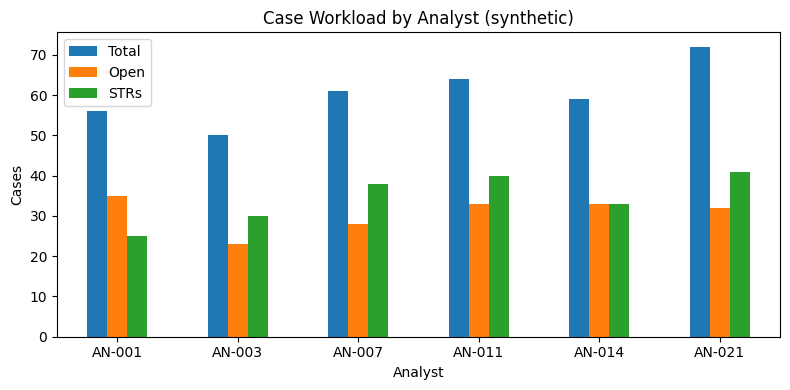

In [6]:
wl = cases.groupby("Analyst_ID").agg(
    Total=("Case_Key","size"),
    Open=("Status", lambda s: (s != "Closed").sum()),
    STRs=("STR_Submitted_Flag","sum")).sort_index()
fig, ax = plt.subplots(figsize=(8,4))
wl[["Total","Open","STRs"]].plot(kind="bar", ax=ax)
ax.set_title("Case Workload by Analyst (synthetic)"); ax.set_xlabel("Analyst"); ax.set_ylabel("Cases")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()


### Chart: aging of open cases

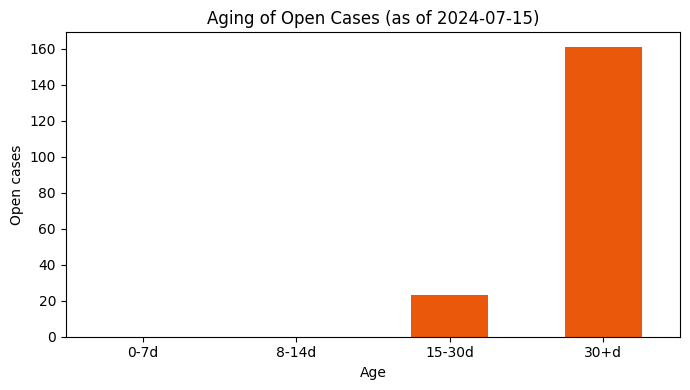

In [7]:
open_cases = cases[cases.Status != "Closed"].copy()
buckets = pd.cut(open_cases.Investigation_Days, bins=[-1,7,14,30,9999],
                 labels=["0-7d","8-14d","15-30d","30+d"])
ages = buckets.value_counts().reindex(["0-7d","8-14d","15-30d","30+d"]).fillna(0)
fig, ax = plt.subplots(figsize=(7,4))
ages.plot(kind="bar", ax=ax, color="#ea580c")
ax.set_title("Aging of Open Cases (as of 2024-07-15)"); ax.set_xlabel("Age"); ax.set_ylabel("Open cases")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()


### Chart: SLA compliance on closed cases

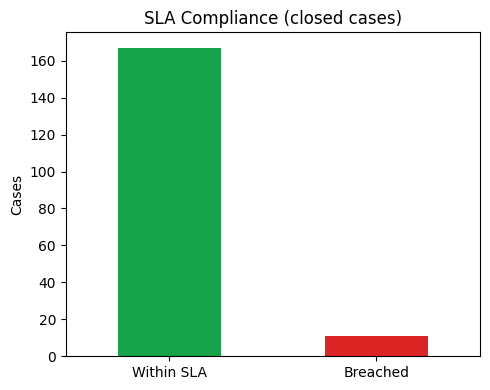

In [8]:
sla = pd.Series({"Within SLA": int((closed.SLA_Breached==0).sum()),
                 "Breached": int((closed.SLA_Breached==1).sum())})
fig, ax = plt.subplots(figsize=(5,4))
sla.plot(kind="bar", ax=ax, color=["#16a34a","#dc2626"])
ax.set_title("SLA Compliance (closed cases)"); ax.set_ylabel("Cases")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()


## 4. Summary

- Escalated alerts convert into a managed case pipeline with statuses, SLAs, and
  analyst ownership — the operational layer FINTRAC expects behind STR filings.
- KPIs (backlog, STR conversion, SLA compliance, aging, analyst workload) are the
  metrics a Compliance lead reviews weekly; they feed the **Phase 8 STR dashboard**.
- STR conversion is higher among true-laundering cases by construction, mirroring how
  investigation confirms genuine suspicion.

**Output:** `data_processed/str_cases.csv` — one row per investigation case.
